In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

from scipy.stats import zscore

## Read All Cleaned Datasets

In [2]:
import pandas as pd

brent_daily = pd.read_csv("cleaned_datasets/brent_daily_clean.csv")
brent_weekly = pd.read_csv("cleaned_datasets/brent_weekly_clean.csv")
brent_monthly = pd.read_csv("cleaned_datasets/brent_monthly_clean.csv")
brent_yearly = pd.read_csv("cleaned_datasets/brent_yearly_clean.csv")

wti_daily = pd.read_csv("cleaned_datasets/wti_daily_clean.csv")
wti_weekly = pd.read_csv("cleaned_datasets/wti_weekly_clean.csv")
wti_monthly = pd.read_csv("cleaned_datasets/wti_monthly_clean.csv")
wti_yearly = pd.read_csv("cleaned_datasets/wti_yearly_clean.csv")

## Store Them in a Dictionary

In [3]:
datasets = {
    "Brent Daily": brent_daily,
    "Brent Weekly": brent_weekly,
    "Brent Monthly": brent_monthly,
    "Brent Yearly": brent_yearly,
    "WTI Daily": wti_daily,
    "WTI Weekly": wti_weekly,
    "WTI Monthly": wti_monthly,
    "WTI Yearly": wti_yearly
}

In [4]:
brent_daily

,Date,Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63
...,...,...
9917,2026-06-23,75.69
9918,2026-06-24,72.09
9919,2026-06-25,73.74
9920,2026-06-26,70.16


In [5]:
for name, df in datasets.items():

    df["Date"] = pd.to_datetime(df["Date"])

    df.sort_values("Date", inplace=True)

    df.set_index("Date", inplace=True)

## Display Basic Information

In [6]:
for name, df in datasets.items():

    print("="*60)

    print(name)

    print(df.info())

    print(df.describe())

Brent Daily
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9922 entries, 1987-05-20 to 2026-06-29
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   9922 non-null   float64
dtypes: float64(1)
memory usage: 155.0 KB
None
             Price
count  9922.000000
mean     51.276754
std      32.772480
min       9.100000
25%      19.580000
50%      46.300000
75%      74.887500
max     143.950000
Brent Weekly
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2042 entries, 1987-05-15 to 2026-06-26
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   2042 non-null   float64
dtypes: float64(1)
memory usage: 31.9 KB
None
             Price
count  2042.000000
mean     51.364398
std      32.859142
min       9.440000
25%      19.560000
50%      46.465000
75%      74.980000
max     141.070000
Brent Monthly
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 470

## Plot the Time Series

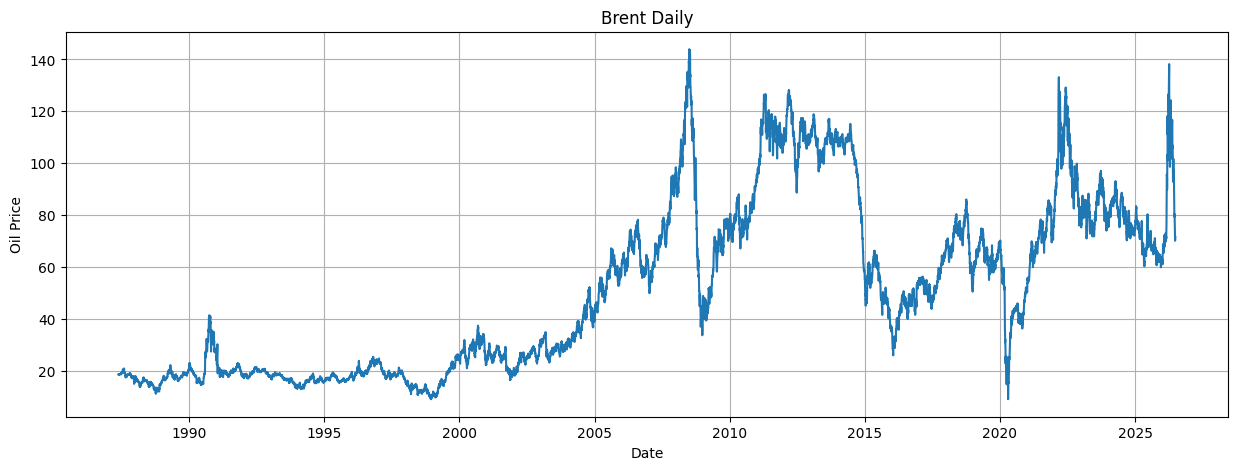

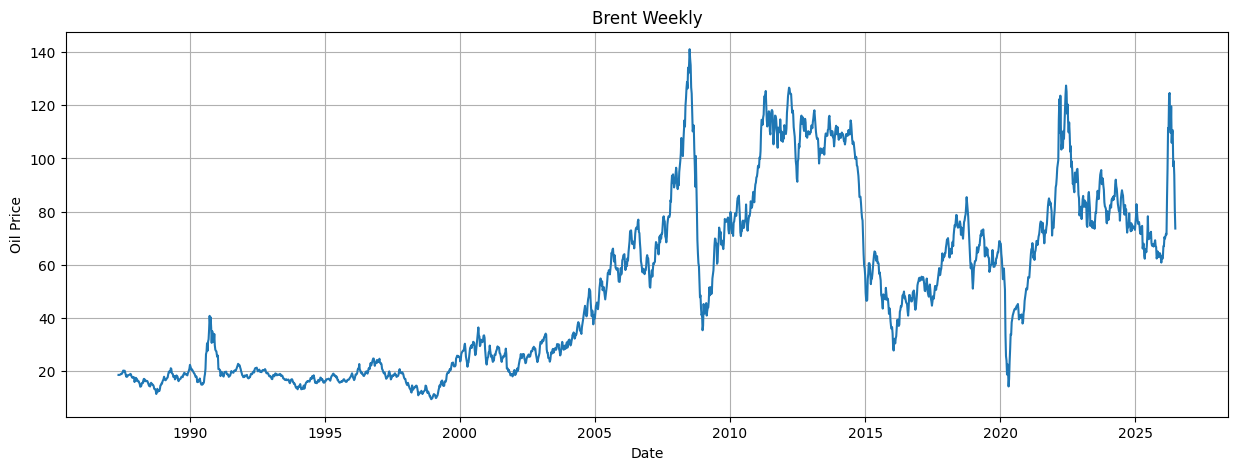

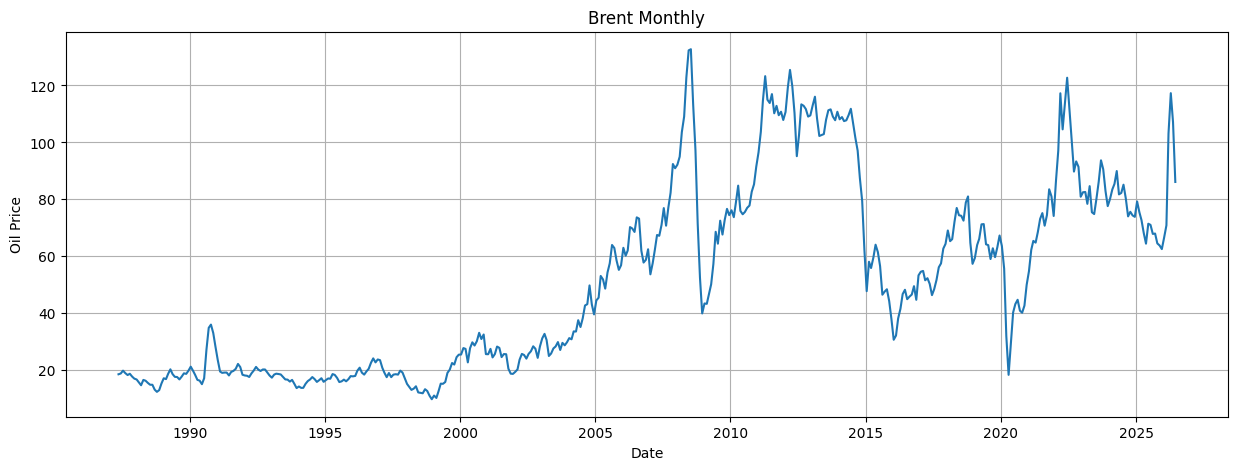

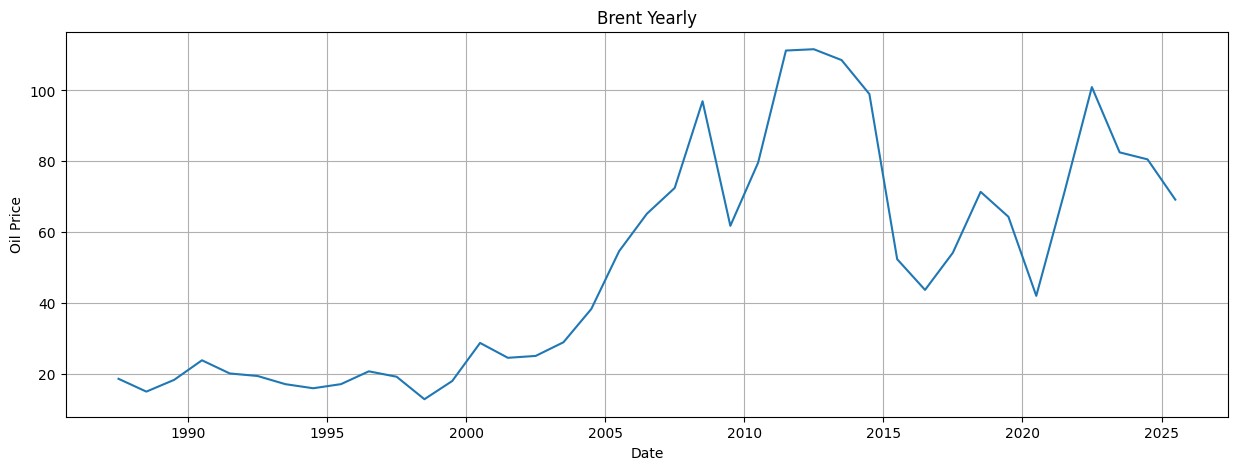

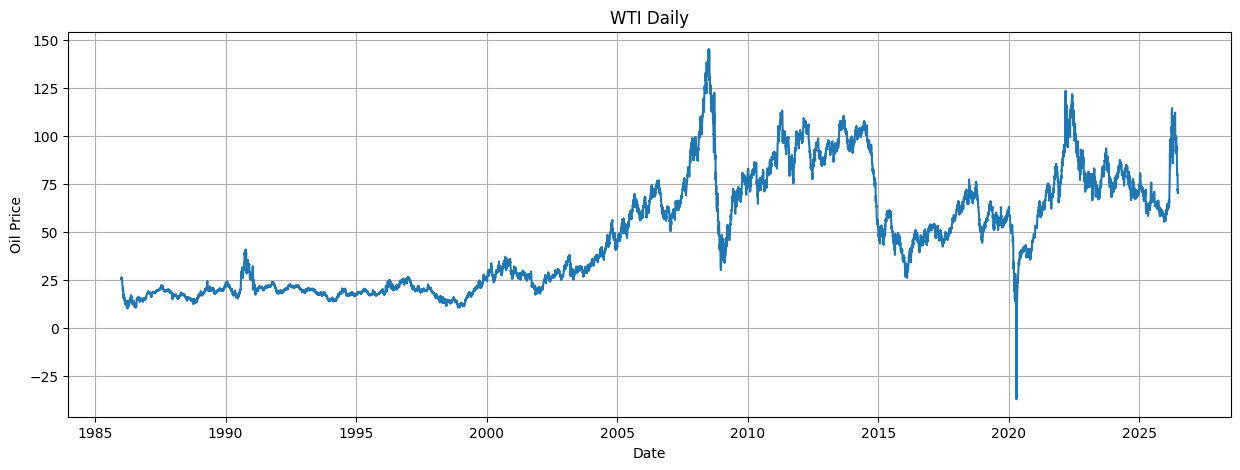

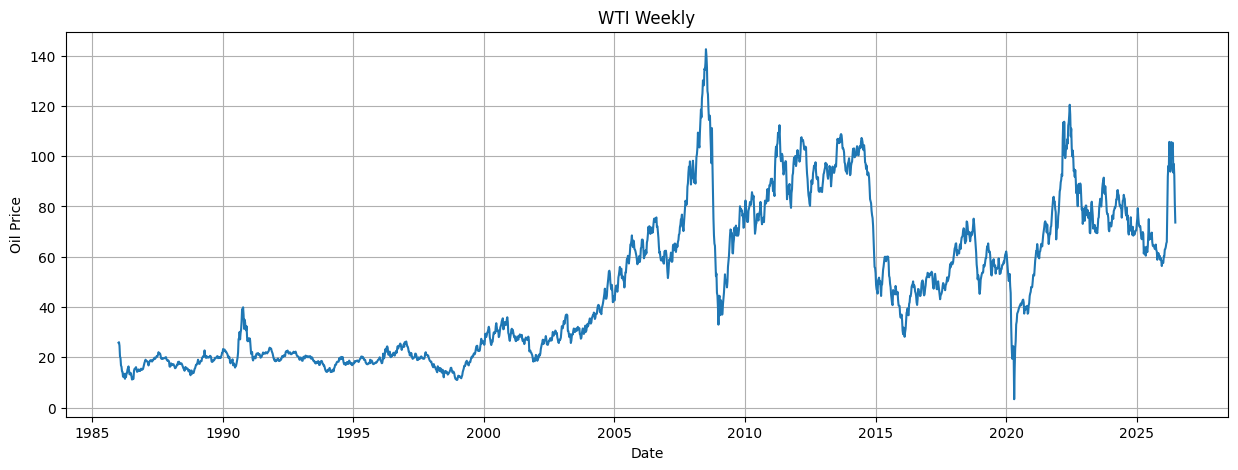

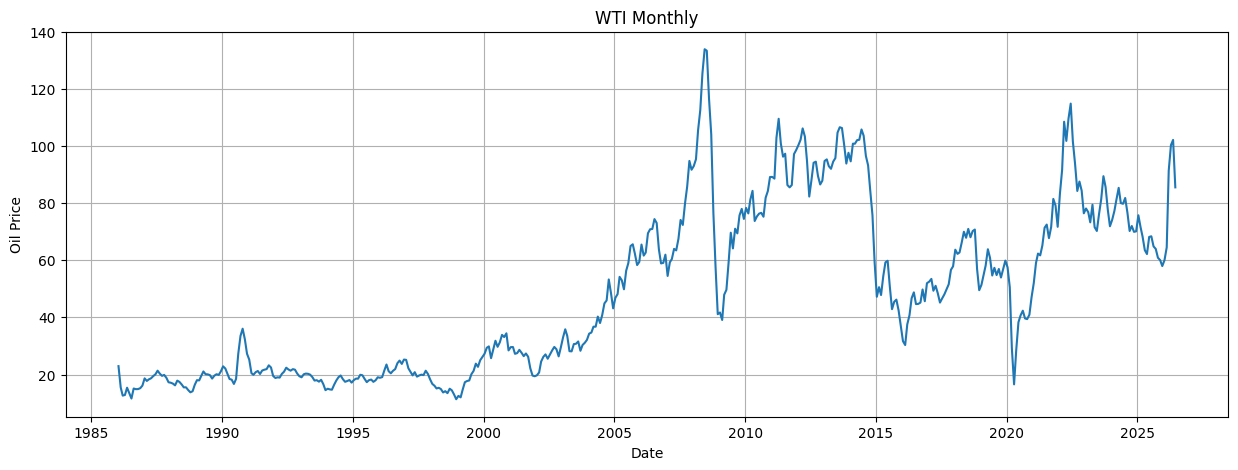

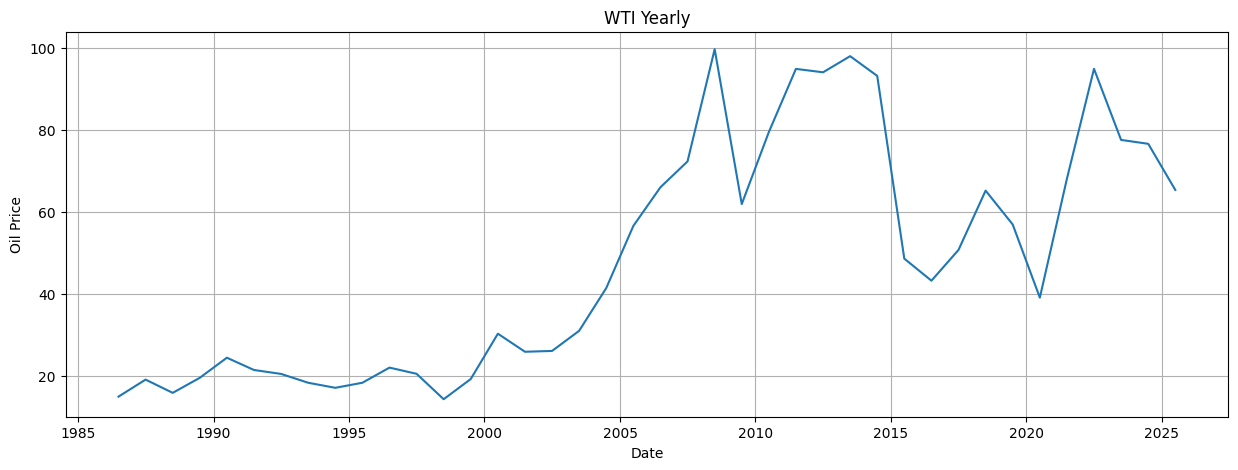

In [7]:
for name, df in datasets.items():

    plt.figure(figsize=(15,5))

    plt.plot(df["Price"])

    plt.title(name)

    plt.xlabel("Date")

    plt.ylabel("Oil Price")

    plt.grid(True)

    plt.show()

## Distribution Plot

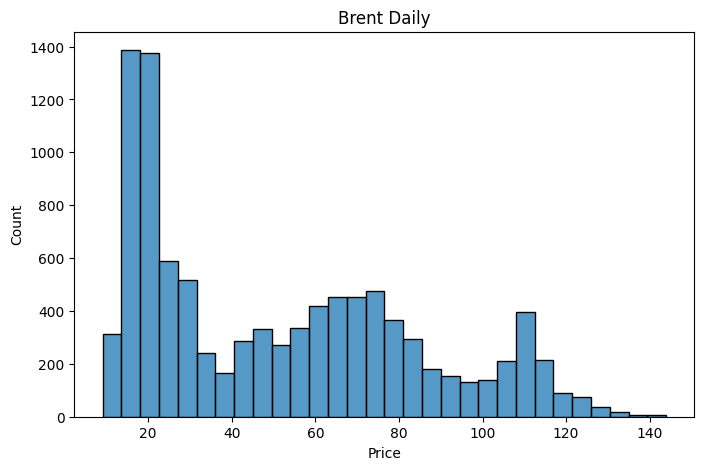

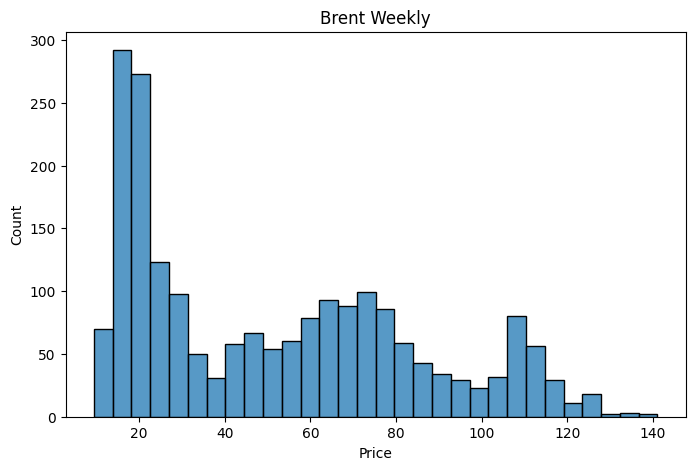

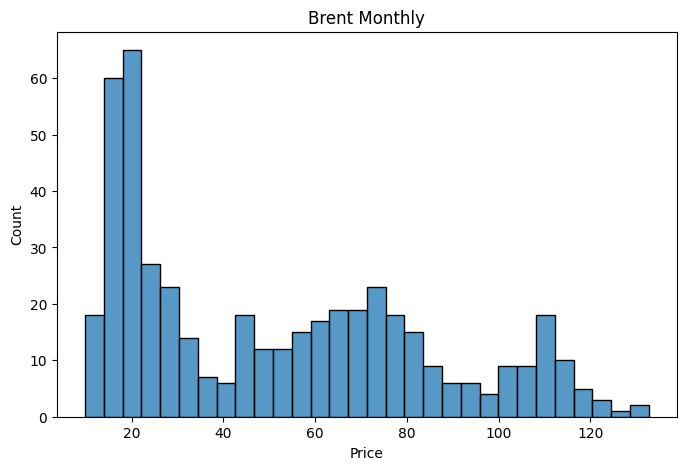

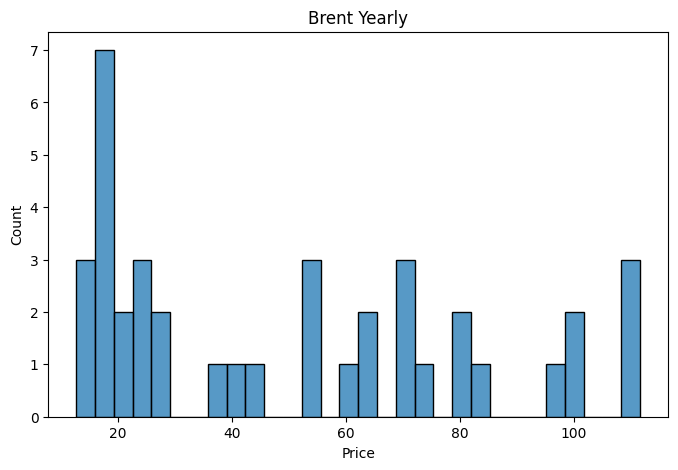

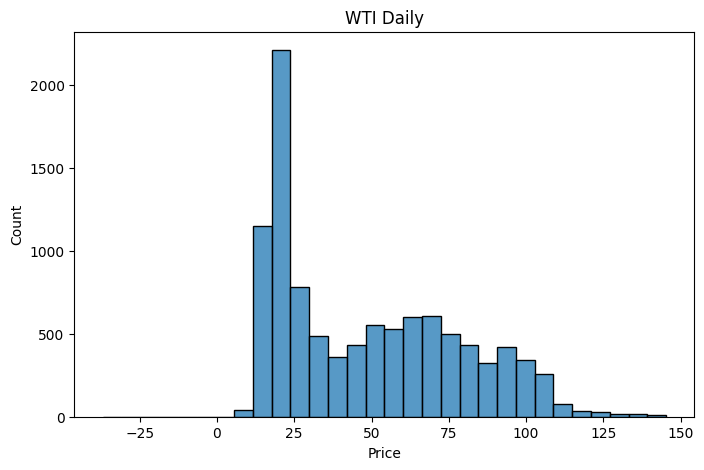

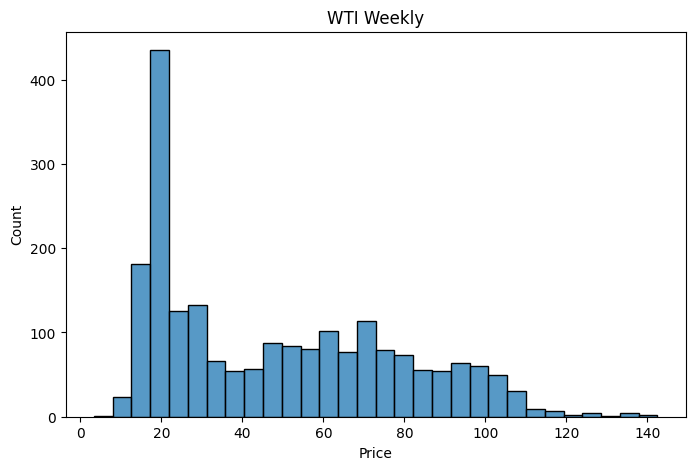

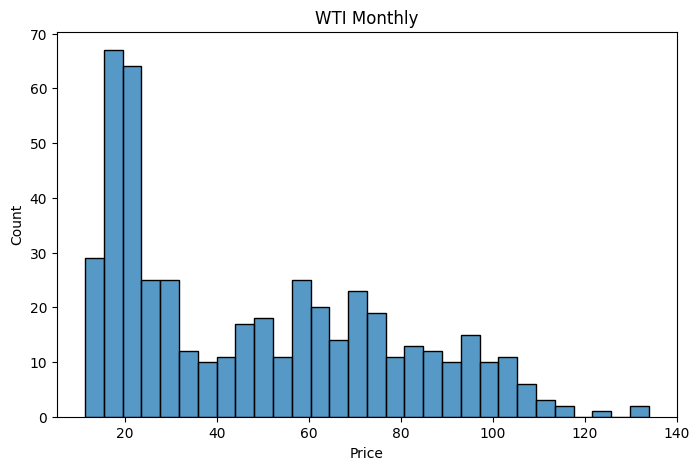

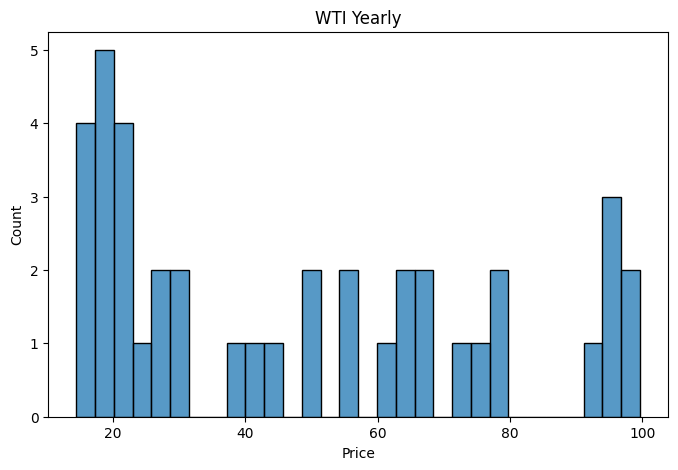

In [8]:
for name, df in datasets.items():

    plt.figure(figsize=(8,5))

    sns.histplot(df["Price"], bins=30)

    plt.title(name)

    plt.show()

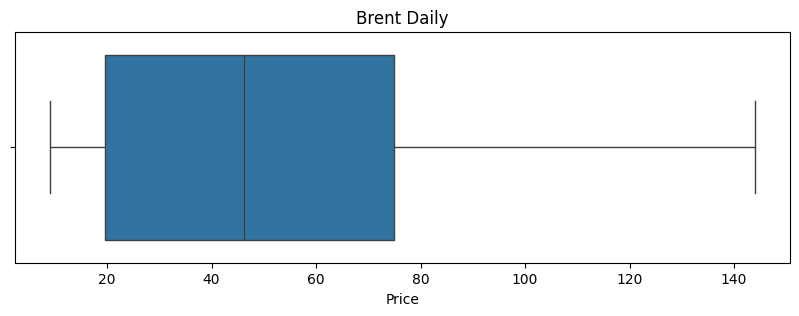

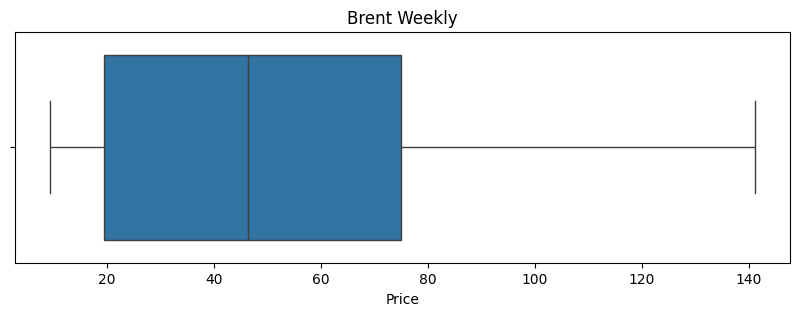

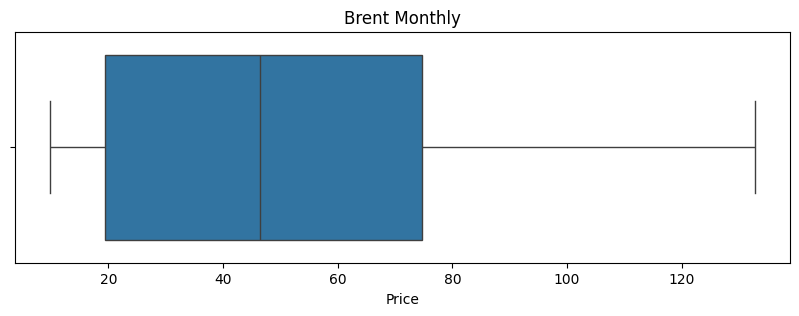

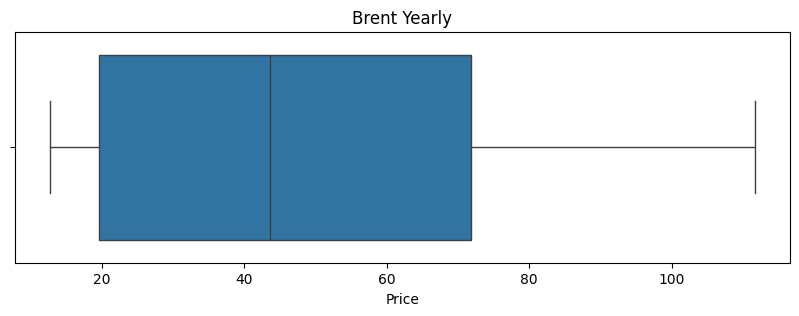

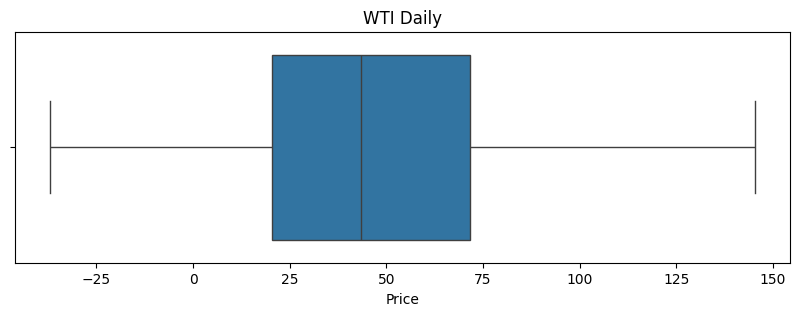

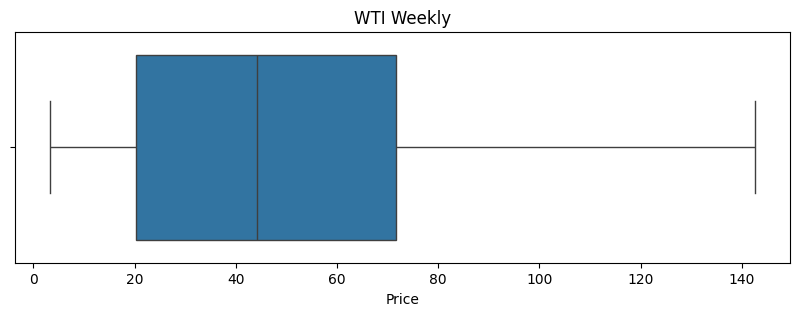

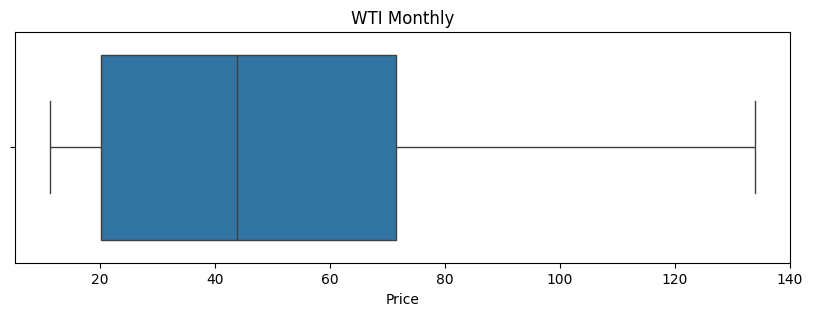

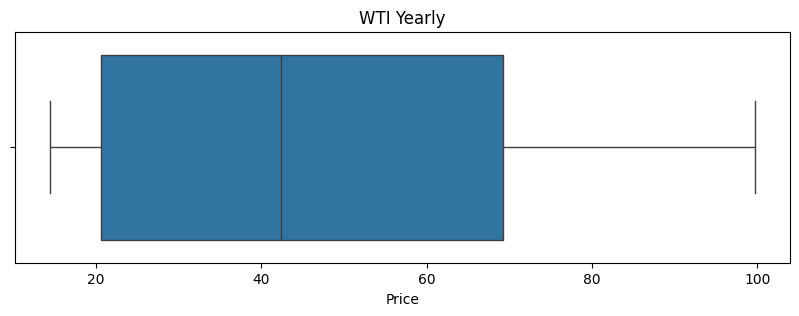

In [9]:
for name, df in datasets.items():

    plt.figure(figsize=(10,3))

    sns.boxplot(x=df["Price"])

    plt.title(name)

    plt.show()

## Checking for Missing Values

In [10]:
for name, df in datasets.items():

    print(name)

    print(df.isnull().sum())

    print()

Brent Daily
Price    0
dtype: int64

Brent Weekly
Price    0
dtype: int64

Brent Monthly
Price    0
dtype: int64

Brent Yearly
Price    0
dtype: int64

WTI Daily
Price    0
dtype: int64

WTI Weekly
Price    0
dtype: int64

WTI Monthly
Price    0
dtype: int64

WTI Yearly
Price    0
dtype: int64



## Seasonal Decomposition

In [11]:
periods = {
    "Brent Daily": 365,
    "Brent Weekly": 52,
    "Brent Monthly": 12,
    "WTI Daily": 365,
    "WTI Weekly": 52,
    "WTI Monthly": 12
}

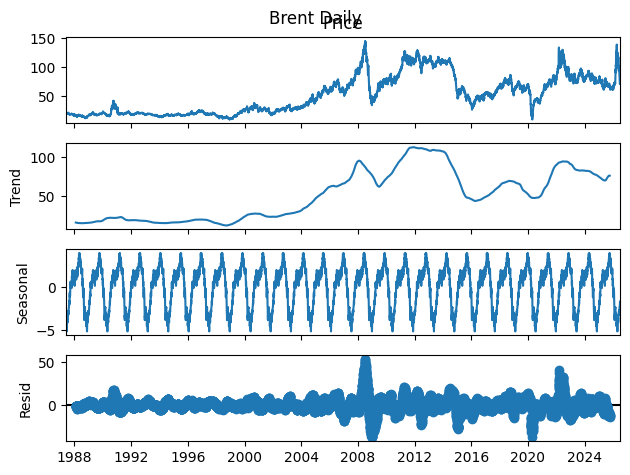

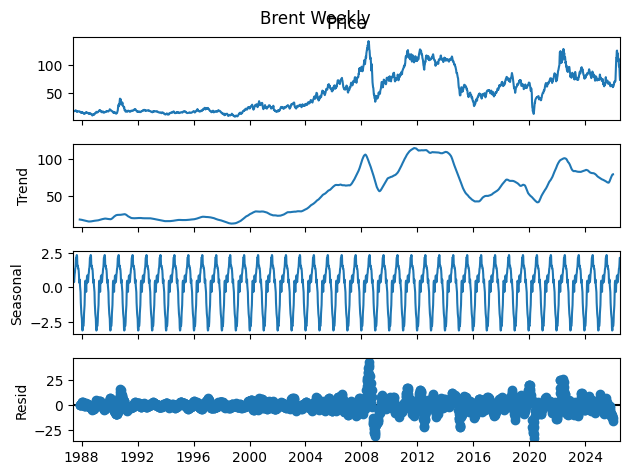

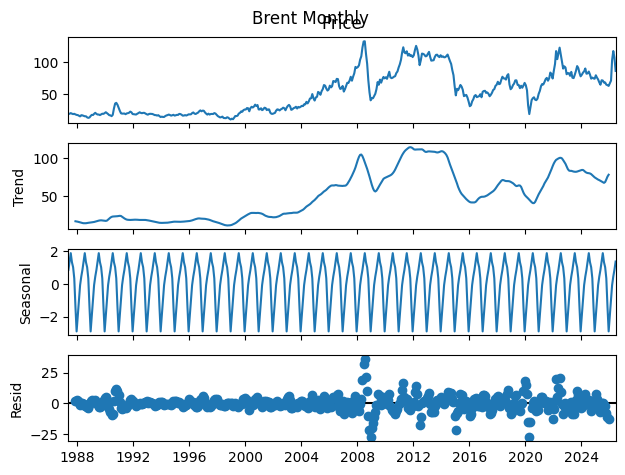

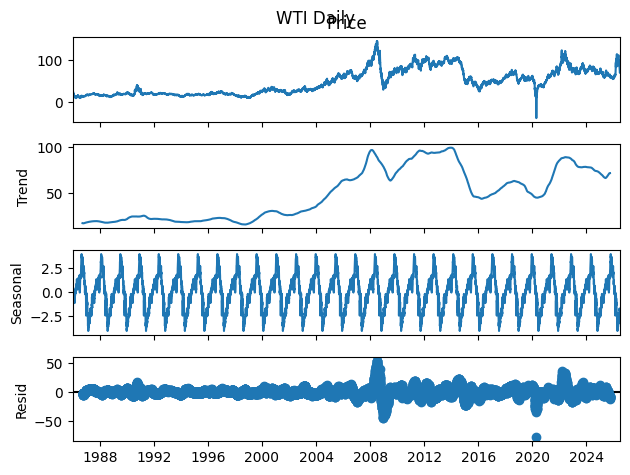

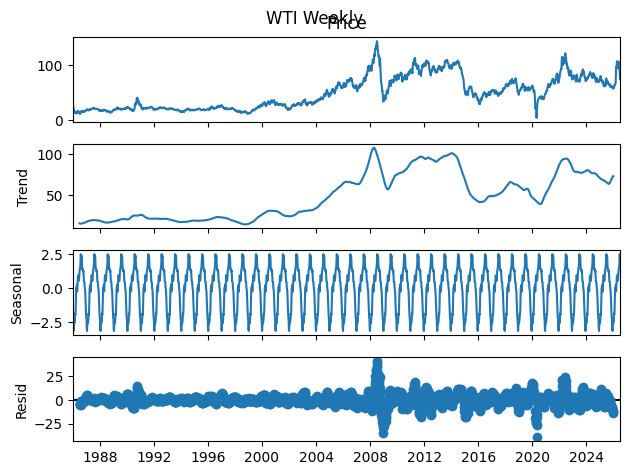

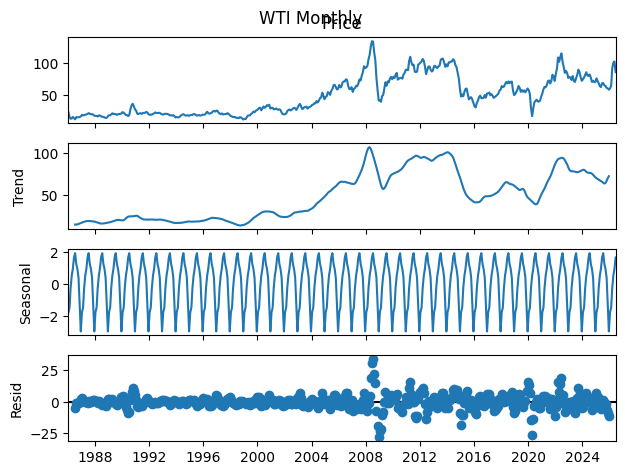

In [12]:
for name, period in periods.items():

    df = datasets[name]

    result = seasonal_decompose(
        df["Price"],
        model="additive",
        period=period
    )

    result.plot()

    plt.suptitle(name)

    plt.show()

## Rolling Mean & Std Deviation

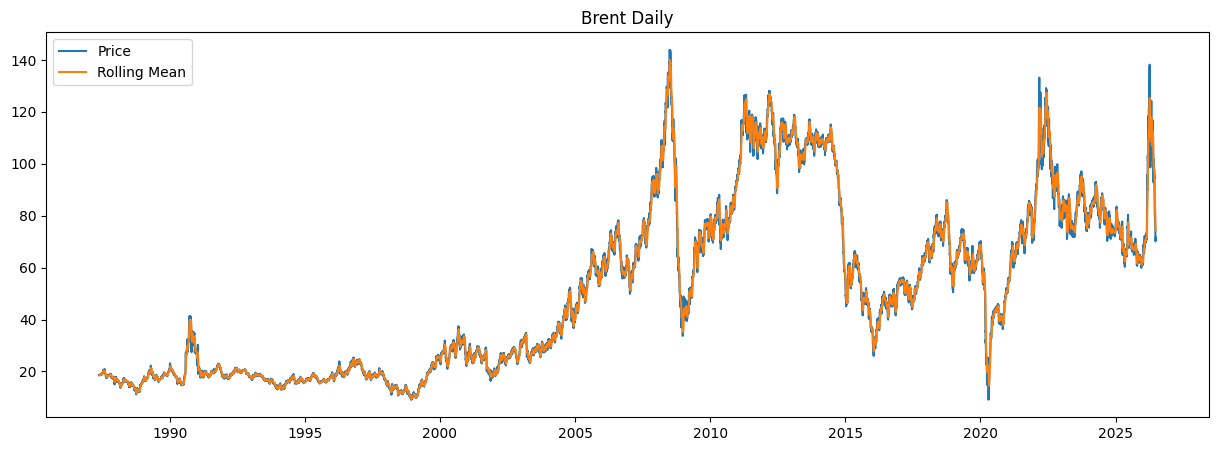

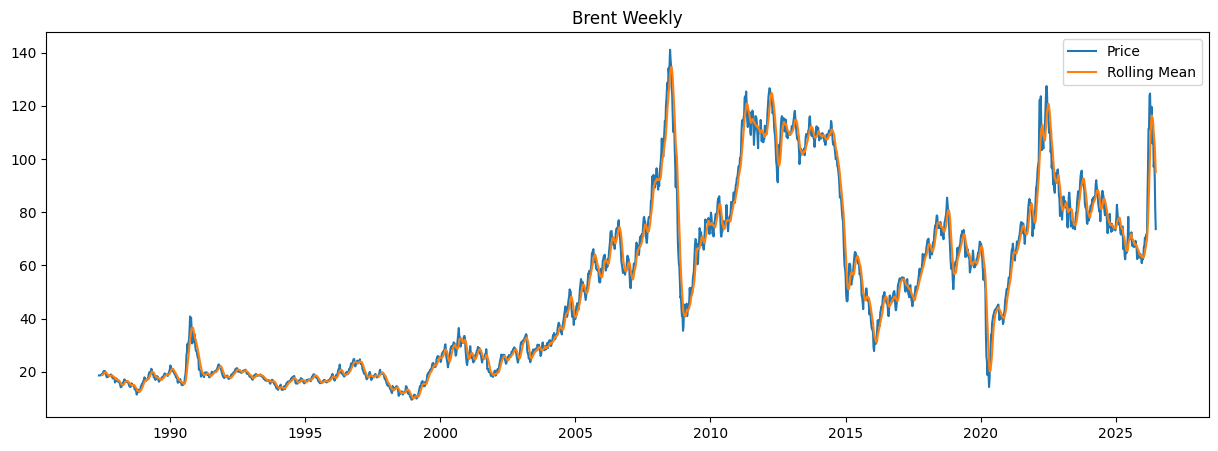

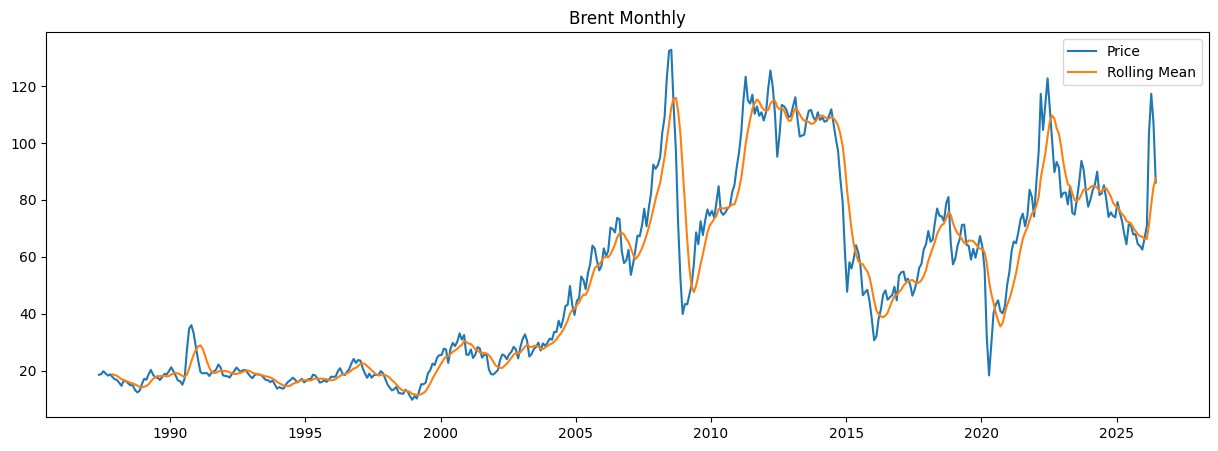

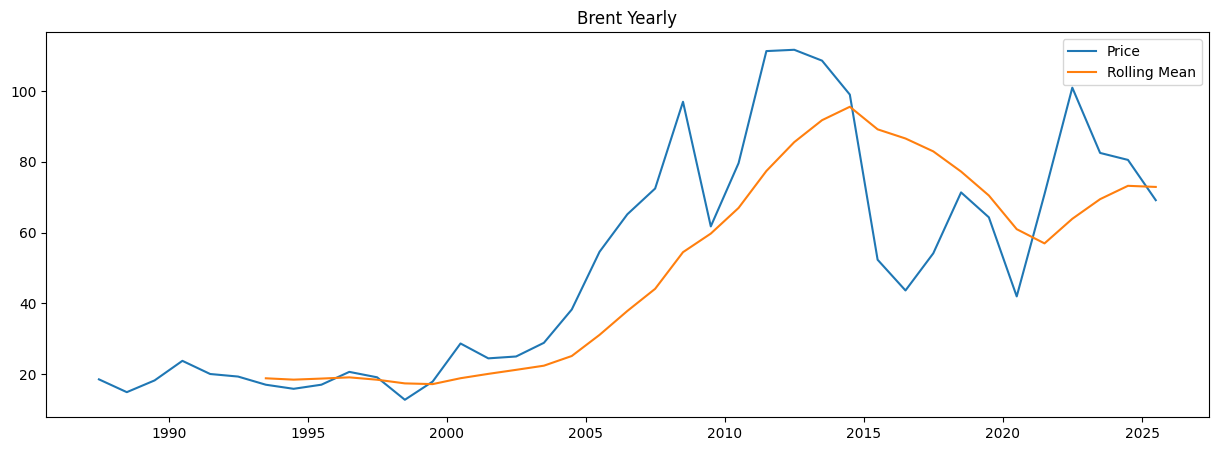

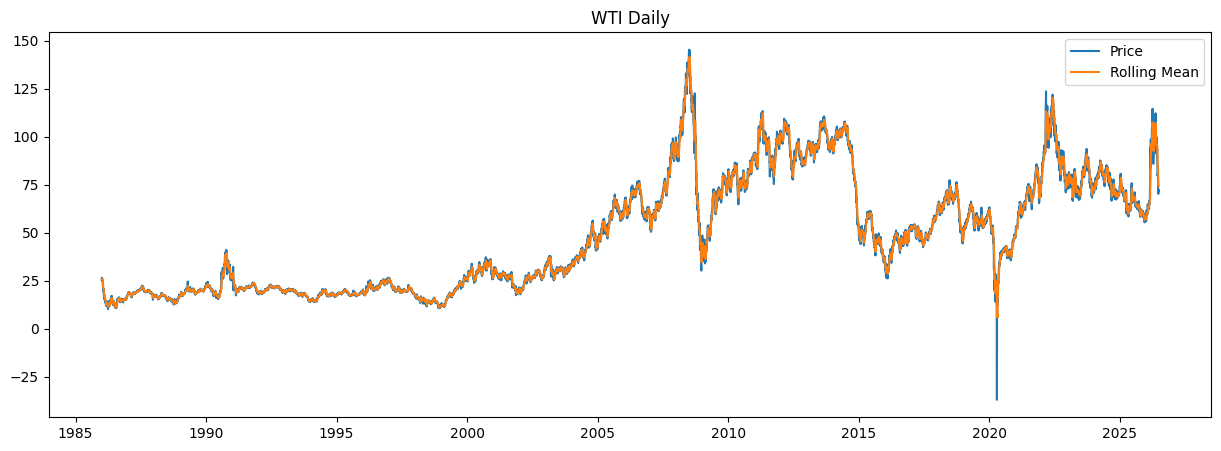

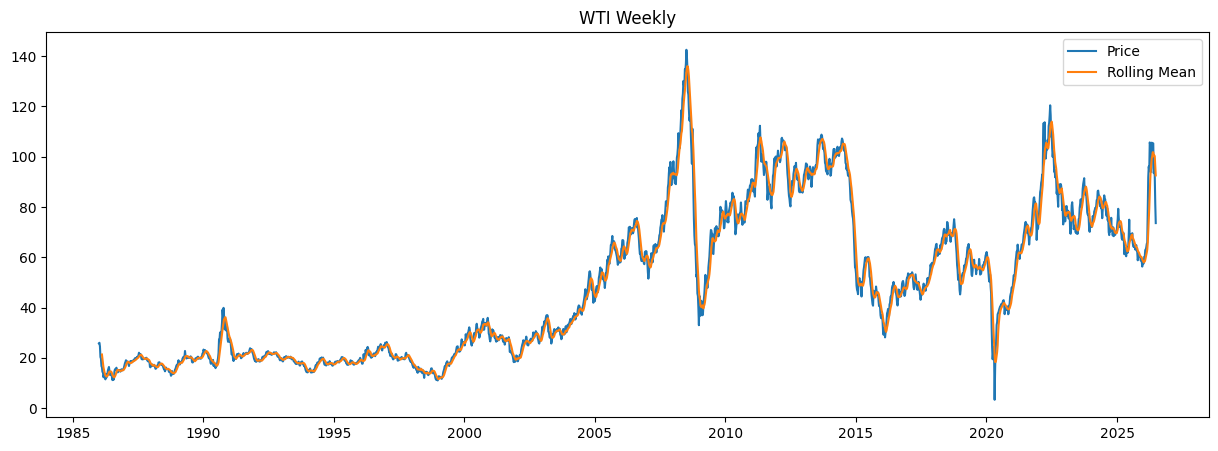

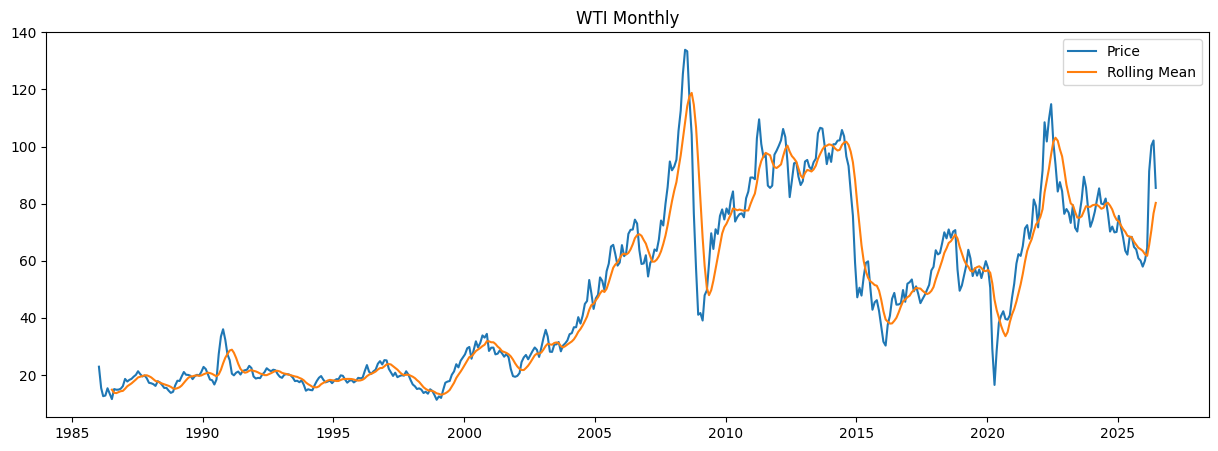

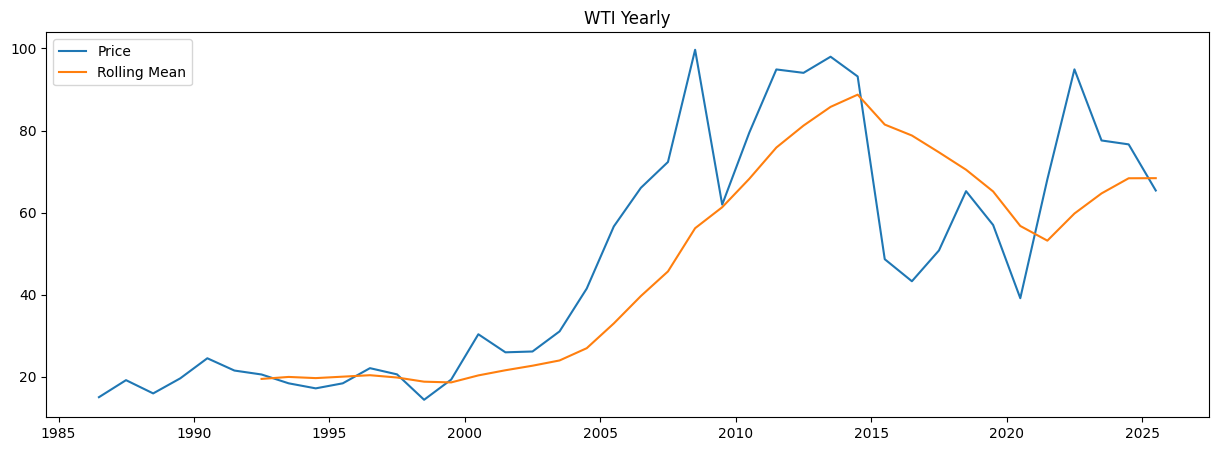

In [13]:
for name, df in datasets.items():

    df["Rolling_Mean"] = df["Price"].rolling(7).mean()

    plt.figure(figsize=(15,5))

    plt.plot(df["Price"], label="Price")

    plt.plot(df["Rolling_Mean"], label="Rolling Mean")

    plt.title(name)

    plt.legend()

    plt.show()

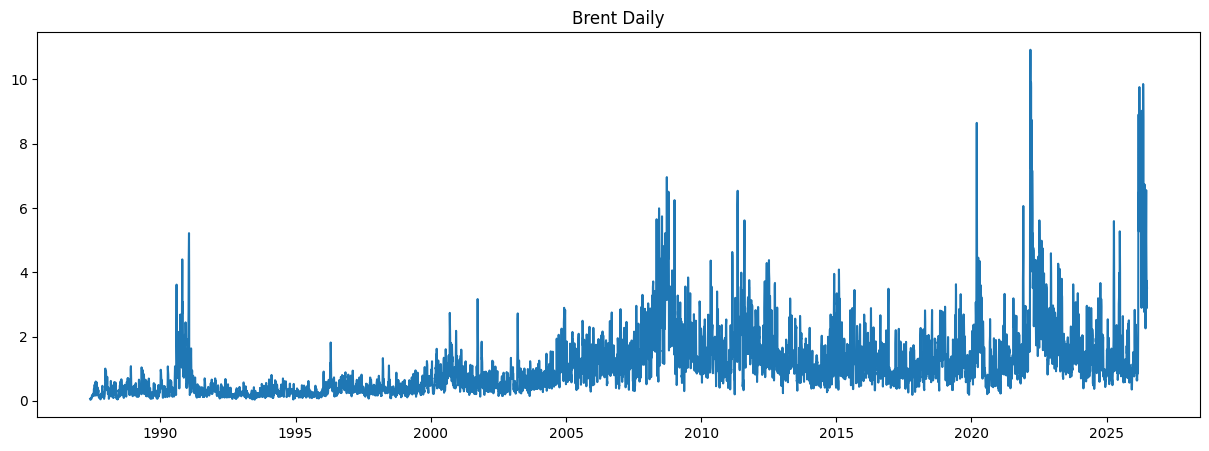

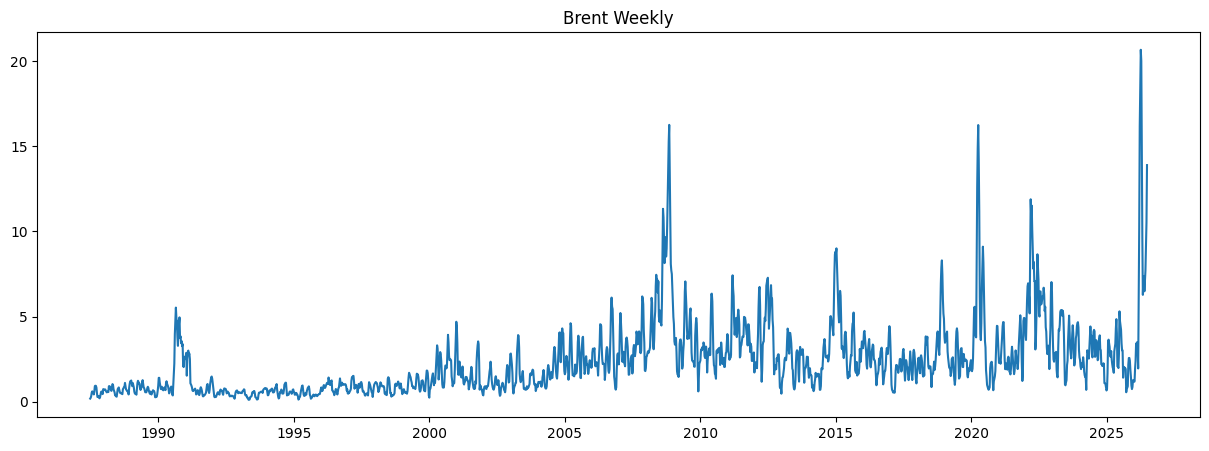

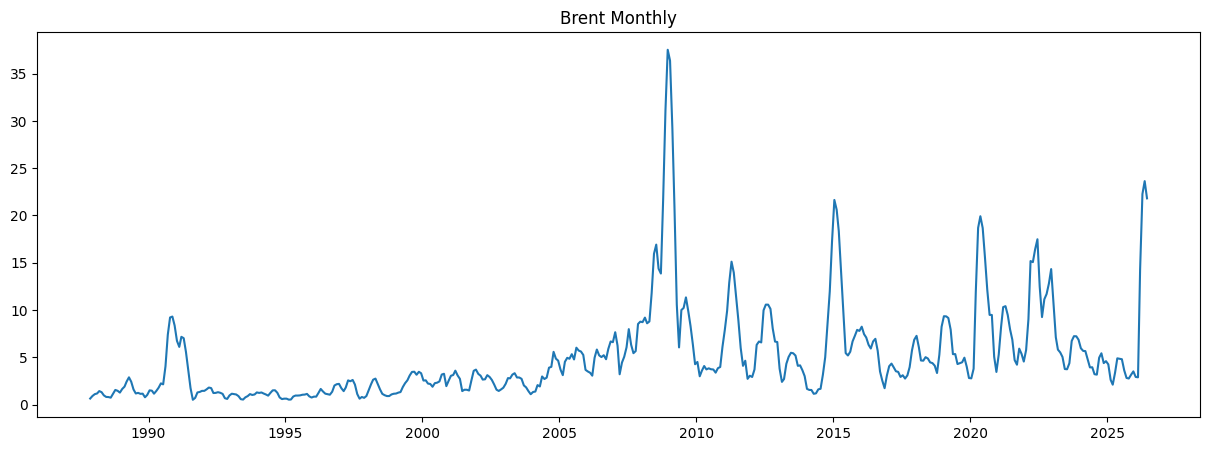

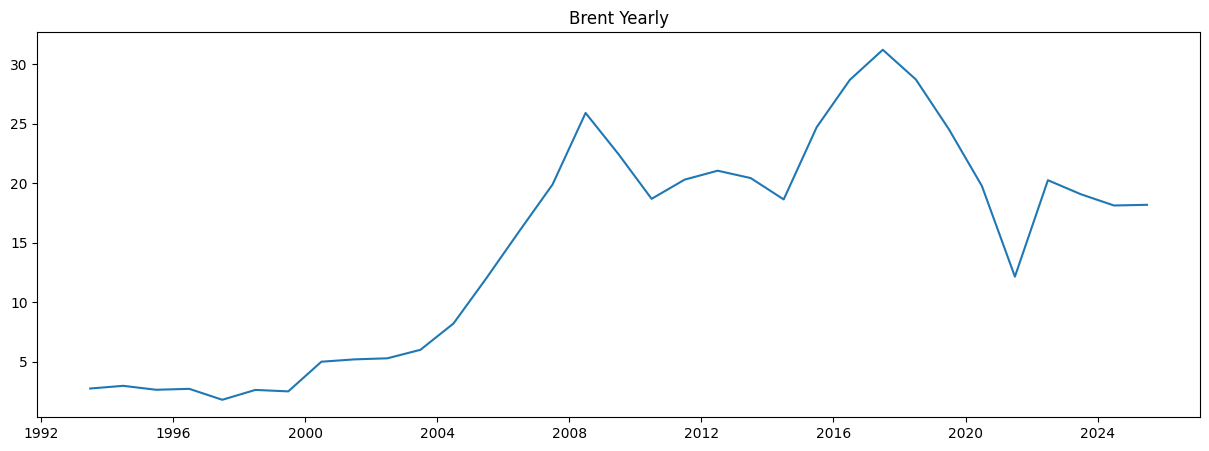

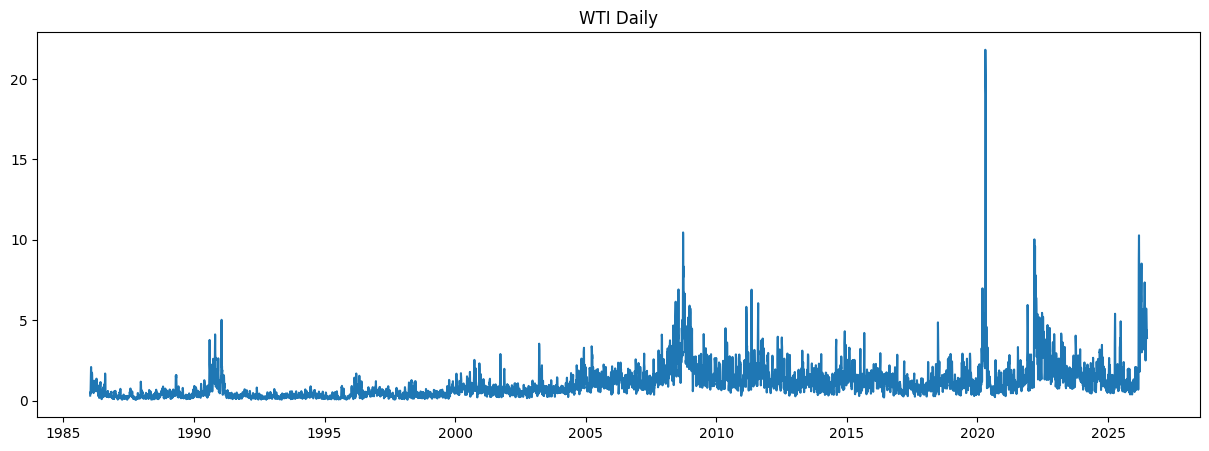

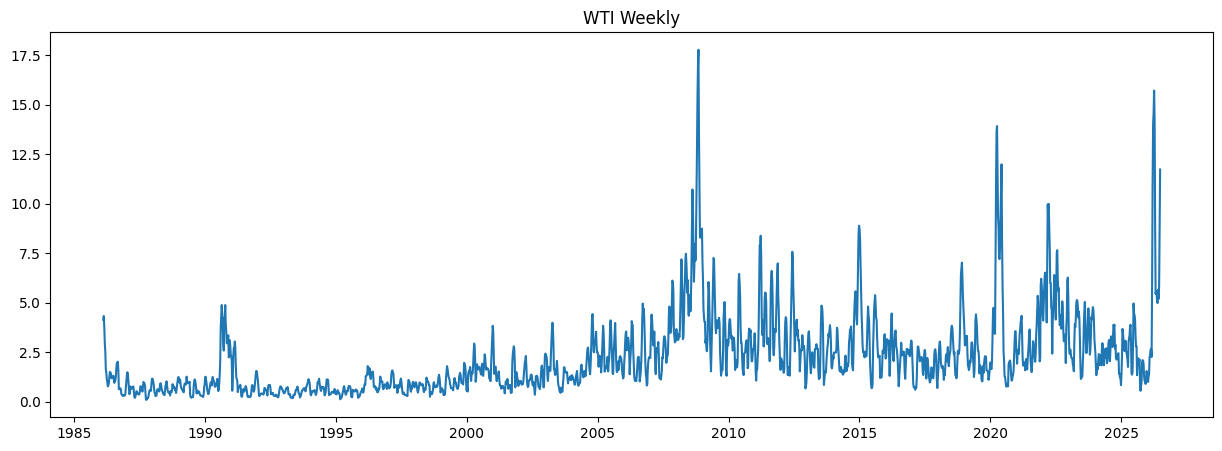

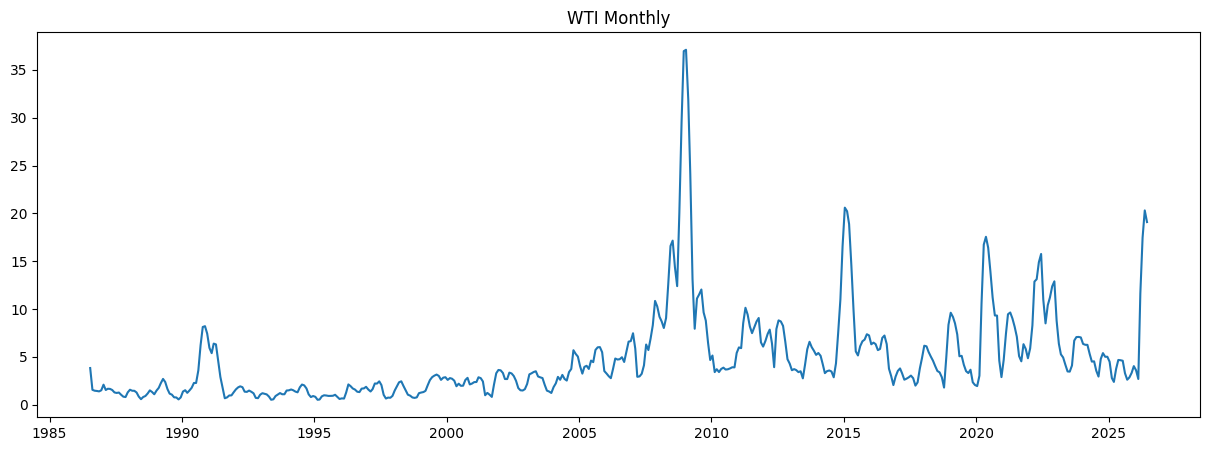

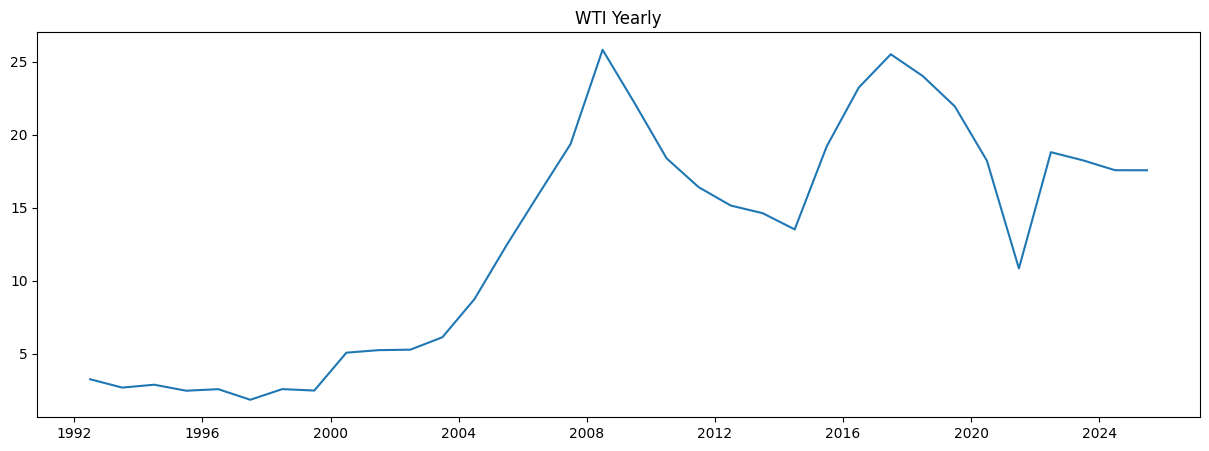

In [14]:
for name, df in datasets.items():

    df["Rolling_STD"] = df["Price"].rolling(7).std()

    plt.figure(figsize=(15,5))

    plt.plot(df["Rolling_STD"])

    plt.title(name)

    plt.show()

The rolling mean analysis of Brent crude oil daily prices demonstrates significant long-term fluctuations and confirms the non-stationary nature of the series. The smoothed trend captures major market movements, including the price decline during the 2008 financial crisis, the prolonged downturn between 2014 and 2016, and the sharp collapse during the COVID-19 pandemic in 2020. The divergence between the original series and rolling mean during crisis periods indicates increased volatility. Since the mean and variance are not constant over time, transformation and stationarity techniques are required before applying forecasting models.

In [15]:
for name, df in datasets.items():

    print("="*60)

    print(name)

    result = adfuller(df["Price"])

    print("ADF Statistic :", result[0])

    print("p-value :", result[1])

Brent Daily
ADF Statistic : -2.5180768722830655
p-value : 0.11113774896372974
Brent Weekly
ADF Statistic : -2.1269798295626106
p-value : 0.23380515468201485
Brent Monthly
ADF Statistic : -1.8509590085433454
p-value : 0.355471225707824
Brent Yearly
ADF Statistic : -1.64857736007195
p-value : 0.4577824789674982
WTI Daily
ADF Statistic : -2.762928176585945
p-value : 0.06376743845963401
WTI Weekly
ADF Statistic : -2.4248635323255705
p-value : 0.13484146821564563
WTI Monthly
ADF Statistic : -1.9927820743650184
p-value : 0.2897468483418568
WTI Yearly
ADF Statistic : -1.758244829815986
p-value : 0.4013800158740822


In [16]:
import os

os.makedirs("preprocessed_datasets", exist_ok=True)

for name, df in datasets.items():

    filename = name.lower().replace(" ", "_") + "_preprocessed.csv"

    df.to_csv(f"preprocessed_datasets/{filename}")